[문제] LSTM 모델을 사용하여 로이터 뉴스 분류하는 프로그램을 작성하시오.

제출형식: 홍길동_0601_정확도.ipynb

참고)
로이터 뉴스 기사 데이터는 총 11,258개의 뉴스 기사가 46개의 뉴스 카테고리로 분류되는 뉴스 기사 데이터다.

<처리조건>
1. 데이터 로드
from tensorflow.keras.datasets import reuters
(X_train, y_train), (X_test, y_test) = reuters.load_data(num_words=None, test_split=0.2)

2. 데이터에 대한 기본적인 전처리 작업을 수행한다.
3. 모델은 정확도가 최적으로 나올수 있도록 설계한다.

In [1]:
import os
import re
import shutil
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
import unicodedata
import urllib3
from tensorflow.keras.layers import Embedding, GRU, Dense, Input, LSTM, Masking, Bidirectional, Dropout
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.datasets import reuters

In [2]:
(X_train, y_train), (X_test, y_test) = reuters.load_data(num_words=None, test_split=0.2)

In [3]:
len(X_train), len(y_train), len(X_test), len(y_test)

(8982, 8982, 2246, 2246)

In [4]:
for i in range(5):
    print(len(X_train[i]))

87
56
139
224
101


In [5]:
sum(len(x) for x in X_train) / len(X_train)

145.5398574927633

In [6]:
max_len = 200

In [7]:
y_train[:2]

array([3, 4], dtype=int64)

In [8]:
X_train = pad_sequences(X_train, maxlen = max_len, padding="pre")
X_test = pad_sequences(X_test, maxlen = max_len, padding="pre")

In [9]:
for i in range(5):
    print(len(X_train[i]))

200
200
200
200
200


In [10]:
max_word_value = max([max(sequence) for sequence in X_train])
vocab_size = max_word_value + 1

print(f"데이터셋의 총 단어 사전 크기(vocab_size): {vocab_size}")

데이터셋의 총 단어 사전 크기(vocab_size): 30980


In [11]:
model = Sequential()
model.add(Embedding(vocab_size, 128, mask_zero=True))
model.add(LSTM(128))
model.add(Dropout(0.3))
model.add(Dense(46, activation='softmax'))
model.build(input_shape=(None, max_len-1))
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=5, batch_size=128, validation_split=0.2, verbose=2)

Epoch 1/5
57/57 - 36s - 640ms/step - accuracy: 0.3673 - loss: 2.6783 - val_accuracy: 0.3817 - val_loss: 2.2513
Epoch 2/5
57/57 - 37s - 643ms/step - accuracy: 0.4493 - loss: 2.1085 - val_accuracy: 0.4964 - val_loss: 1.9479
Epoch 3/5
57/57 - 29s - 506ms/step - accuracy: 0.5237 - loss: 1.8602 - val_accuracy: 0.5320 - val_loss: 1.8919
Epoch 4/5
57/57 - 41s - 727ms/step - accuracy: 0.5425 - loss: 1.7771 - val_accuracy: 0.5231 - val_loss: 1.8147
Epoch 5/5
57/57 - 29s - 510ms/step - accuracy: 0.5687 - loss: 1.6420 - val_accuracy: 0.5810 - val_loss: 1.6898


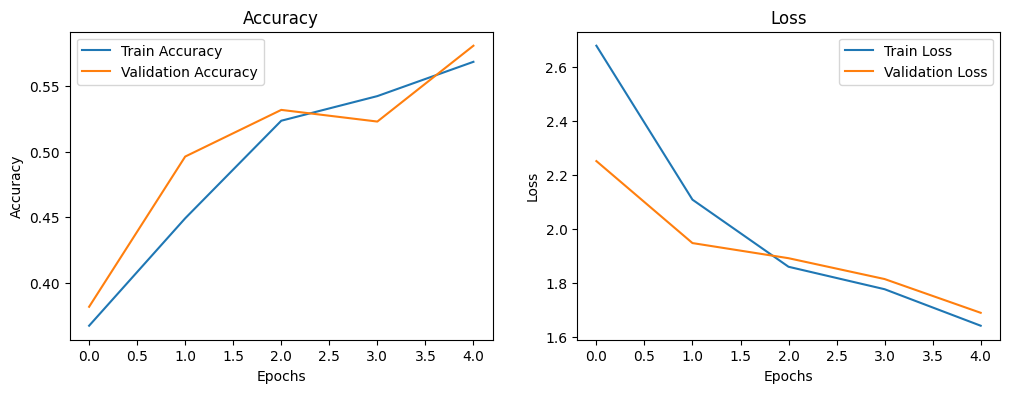

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# 정확도(Accuracy) 그래프
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 손실(Loss) 그래프
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [13]:
model.evaluate(X_test, y_test, verbose=2)

71/71 - 4s - 58ms/step - accuracy: 0.5744 - loss: 1.7092


[1.7091588973999023, 0.5743544101715088]

In [14]:
model = Sequential()
model.add(Embedding(vocab_size, 128, mask_zero=True))
model.add(Bidirectional(LSTM(128)))
model.add(Dropout(0.3))
model.add(Dense(46, activation='softmax'))
model.build(input_shape=(None, max_len-1))
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=5, batch_size=128, validation_split=0.2, verbose=2)

Epoch 1/5
57/57 - 49s - 862ms/step - accuracy: 0.4366 - loss: 2.3086 - val_accuracy: 0.5437 - val_loss: 1.7334
Epoch 2/5
57/57 - 44s - 764ms/step - accuracy: 0.5562 - loss: 1.6831 - val_accuracy: 0.6088 - val_loss: 1.5787
Epoch 3/5
57/57 - 29s - 508ms/step - accuracy: 0.6189 - loss: 1.4469 - val_accuracy: 0.6132 - val_loss: 1.5028
Epoch 4/5
57/57 - 28s - 490ms/step - accuracy: 0.6821 - loss: 1.2280 - val_accuracy: 0.6628 - val_loss: 1.3602
Epoch 5/5
57/57 - 30s - 524ms/step - accuracy: 0.7360 - loss: 1.0288 - val_accuracy: 0.6778 - val_loss: 1.2878


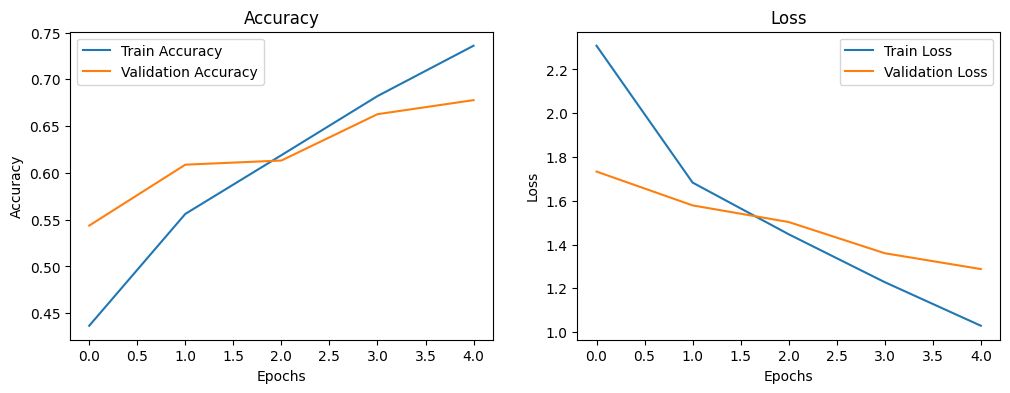

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# 정확도(Accuracy) 그래프
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 손실(Loss) 그래프
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [16]:
model.evaluate(X_test, y_test, verbose=2)

71/71 - 2s - 27ms/step - accuracy: 0.6638 - loss: 1.3514


[1.3513857126235962, 0.6638468503952026]

In [17]:
history = model.fit(X_train, y_train, epochs=15, batch_size=128, validation_split=0.2, verbose=2)

Epoch 1/15
57/57 - 29s - 500ms/step - accuracy: 0.7807 - loss: 0.8452 - val_accuracy: 0.7017 - val_loss: 1.2582
Epoch 2/15
57/57 - 27s - 472ms/step - accuracy: 0.8125 - loss: 0.7228 - val_accuracy: 0.7078 - val_loss: 1.2233
Epoch 3/15
57/57 - 29s - 506ms/step - accuracy: 0.8335 - loss: 0.6477 - val_accuracy: 0.7023 - val_loss: 1.2813
Epoch 4/15
57/57 - 29s - 513ms/step - accuracy: 0.8611 - loss: 0.5473 - val_accuracy: 0.7168 - val_loss: 1.2711
Epoch 5/15
57/57 - 28s - 483ms/step - accuracy: 0.8820 - loss: 0.4503 - val_accuracy: 0.7262 - val_loss: 1.2619
Epoch 6/15
57/57 - 27s - 476ms/step - accuracy: 0.9087 - loss: 0.3683 - val_accuracy: 0.7117 - val_loss: 1.3696
Epoch 7/15
57/57 - 27s - 477ms/step - accuracy: 0.9061 - loss: 0.3708 - val_accuracy: 0.7140 - val_loss: 1.3357
Epoch 8/15
57/57 - 29s - 503ms/step - accuracy: 0.9290 - loss: 0.2908 - val_accuracy: 0.7212 - val_loss: 1.3688
Epoch 9/15
57/57 - 31s - 536ms/step - accuracy: 0.9390 - loss: 0.2420 - val_accuracy: 0.7206 - val_loss:

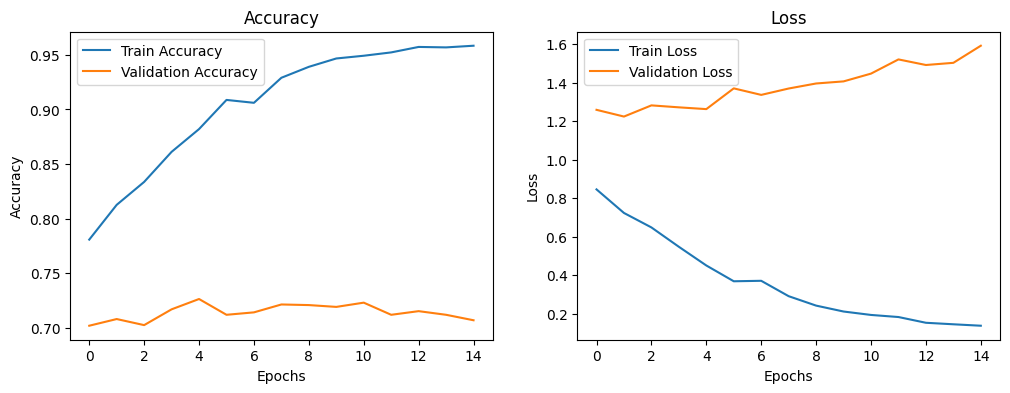

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# 정확도(Accuracy) 그래프
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 손실(Loss) 그래프
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [19]:
model.evaluate(X_test, y_test, verbose=2)

71/71 - 2s - 29ms/step - accuracy: 0.7075 - loss: 1.6573


[1.6573429107666016, 0.7074799537658691]

In [25]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model = Sequential()
model.add(Embedding(vocab_size, 128, mask_zero=True))
model.add(Bidirectional(LSTM(128)))
model.add(Dropout(0.3))
model.add(Dense(46, activation='softmax'))
model.build(input_shape=(None, max_len-1))
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=4)

mc = ModelCheckpoint('best_model.keras', monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)

history = model.fit(X_train, y_train, 
                    epochs=25, 
                    batch_size=128, 
                    validation_split=0.2, 
                    callbacks=[es, mc], 
                    verbose=2)

Epoch 1/25

Epoch 1: val_accuracy improved from None to 0.54090, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
57/57 - 32s - 557ms/step - accuracy: 0.4299 - loss: 2.3198 - val_accuracy: 0.5409 - val_loss: 1.7645
Epoch 2/25

Epoch 2: val_accuracy improved from 0.54090 to 0.59265, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
57/57 - 24s - 425ms/step - accuracy: 0.5816 - loss: 1.6319 - val_accuracy: 0.5927 - val_loss: 1.5771
Epoch 3/25

Epoch 3: val_accuracy improved from 0.59265 to 0.64329, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
57/57 - 24s - 420ms/step - accuracy: 0.6367 - loss: 1.4152 - val_accuracy: 0.6433 - val_loss: 1.4172
Epoch 4/25

Epoch 4: val_accuracy improved from 0.64329 to 0.66611, saving model to best_model.keras

Epoch 4: finished saving model to best_model.keras
57/57 - 24s - 418ms/step - accuracy: 0.6892 - loss: 1.2378 - val_accuracy: 0.6661 - val_

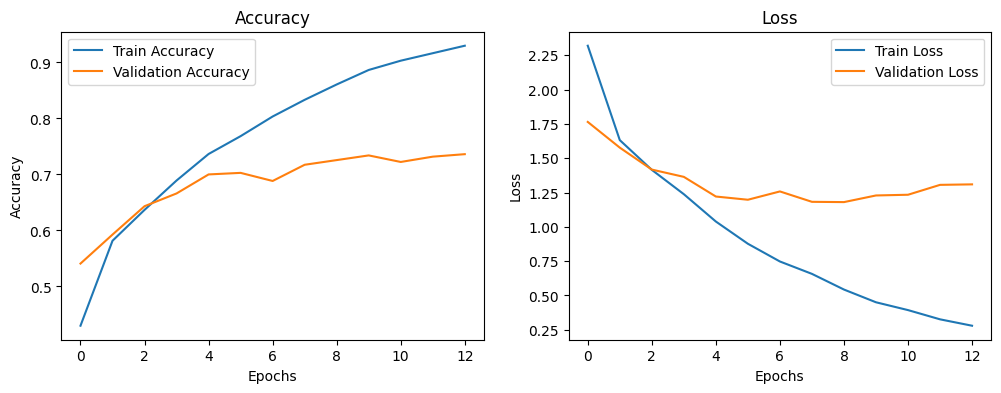

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# 정확도(Accuracy) 그래프
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 손실(Loss) 그래프
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [27]:
best_model = tf.keras.models.load_model('best_model.keras')
best_model.evaluate(X_test, y_test, verbose=2)

71/71 - 3s - 39ms/step - accuracy: 0.7240 - loss: 1.4026


[1.4025936126708984, 0.7239537239074707]